In [67]:
import os
os.chdir("/Users/srujansingh/Documents/JeanFan_Lab/Kidney_Structural_Analysis/")

In [68]:
import scanpy as sc
#ctrl1_data only contains the all the tubule annotations:
ctrl1_data = sc.read_h5ad("data/2um/Ctrl_1A2/Ctrl_1A2_visiumhd_2um_proximal_labeled.h5ad")
ctrl1_data.obs.shape

(5549563, 6)

In [69]:
#Subset the AnnData to only contain proximal tubules
ctrl1_A2_PT=ctrl1_data[~ctrl1_data.obs['proximal_tubule_geojson_feature_index'].isna()]
ctrl1_A2_PT.shape #to check the dimensions of the subset matrix.
ctrl1_A2_PT.obs

,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,proximal_tubule_geojson_feature_index
s_002um_00304_00021-1,1,304,21,2407.153091,18011.820723,929
s_002um_00304_00022-1,1,304,22,2407.205739,18007.281833,929
s_002um_00304_00023-1,1,304,23,2407.258388,18002.742943,929
s_002um_00304_00024-1,1,304,24,2407.311036,17998.204053,929
s_002um_00304_00025-1,1,304,25,2407.363684,17993.665163,929
...,...,...,...,...,...,...
s_002um_03081_00927-1,1,3081,927,15050.493122,14042.298862,5938
s_002um_03081_00928-1,1,3081,928,15050.545696,14037.759889,5938
s_002um_03081_00929-1,1,3081,929,15050.598270,14033.220917,5938
s_002um_03081_00930-1,1,3081,930,15050.650844,14028.681944,5938


In [194]:
#Importing the geojson files which contains the proximal tubule annotations and boudary information.
import geopandas as gpd
gdf=gpd.read_file("data/2um/geojson/Ctrl_1A2_tubules_processed_caleb.geojson")
gdf.head()
gdf.shape

(11653, 6)

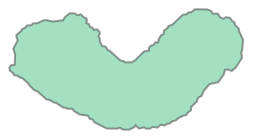

In [195]:
#Sanity Check
tubule=gdf[gdf["id"]=="929"]
geom=tubule.geometry.iloc[0]
geom

In [196]:
#Remove invlid geojsons:
gdf = gdf[gdf.geometry.notna()]
gdf = gdf[~gdf.geometry.is_empty]
gdf = gdf[gdf.is_valid]
gdf.shape

(11644, 6)

In [201]:
#Bootstrapping a few oproximal tubule instances to perform linear regression on:
import pandas as pd

PT_id=ctrl1_A2_PT.obs['proximal_tubule_geojson_feature_index'].unique()
PT_id_rand=pd.Series(PT_id).sample(n=5, random_state=53) #randomly select 10 proximal tubule (geojson IDs)
print(PT_id_rand.tolist())

print(len(subset))


[1924, 4644, 876, 441, 4575]
389


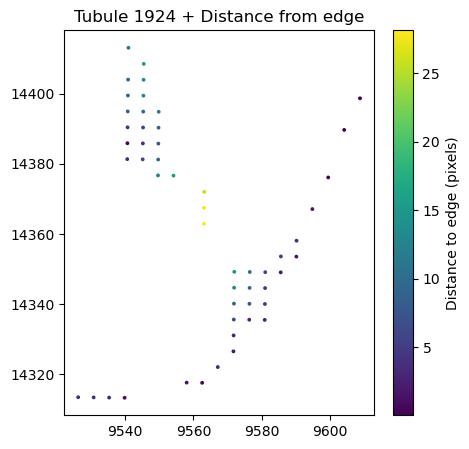

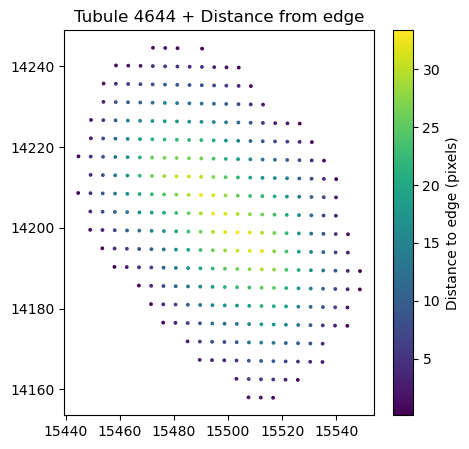

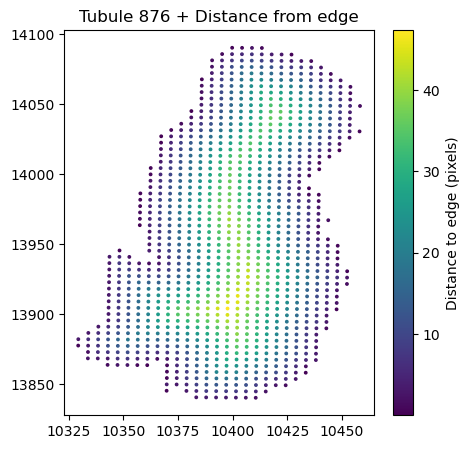

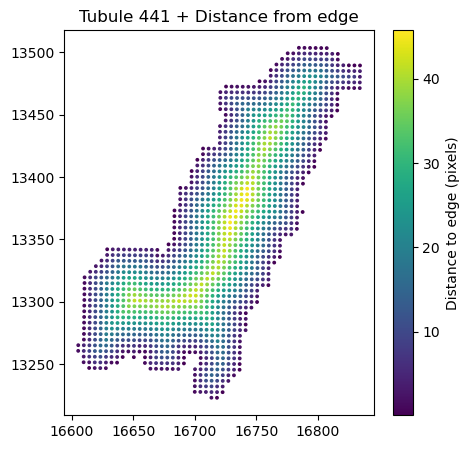

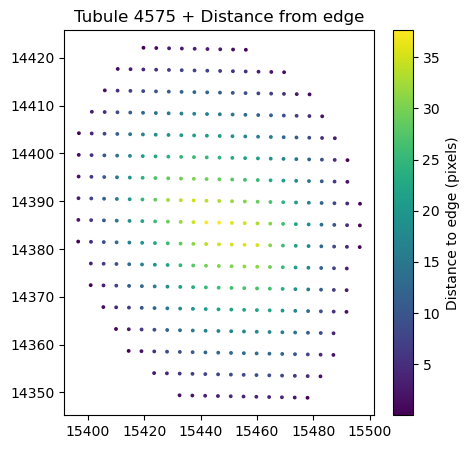

In [210]:
for ptid in PT_id_rand.tolist():
  
   #print(ptid) #to check what proximal tubule are we working with?

   tubule=gdf[gdf["id"]==str(ptid)]
   #if tubule.empty:
    #print(f"Skipping ptid={ptid} (not found in gdf)")
    #continue
   #else:
     #print("Tubule geometry is ok") 
   
   geom=tubule.geometry.iloc[0] 
   #print(geom) #to check the associated geometry with the corresponding proximal tubule.

   subset = ctrl1_A2_PT[ctrl1_A2_PT.obs['proximal_tubule_geojson_feature_index'].astype(str) == str(ptid)].copy() #subset contains only 929 PT 2um bins.

   x = subset.obs["pxl_col_in_fullres"]
   y = subset.obs["pxl_row_in_fullres"]
   #print(x.head())

   #Convert bins to shapely points:
   from shapely.geometry import Point
   points = [Point(xy) for xy in zip(x, y)]

   #Extract the polygon boundary:
   boundary = geom.boundary

   #Computing distance to edge:
   distances = [p.distance(boundary) for p in points]

   #Append this new distance matrix into the subset data:
   subset.obs["dist_to_edge"] = distances

   #print(subset.obs.head())

   #Plot/Overlay
   import matplotlib.pyplot as plt
   fig, ax = plt.subplots(figsize=(5,5))
  
   # plotting the polygon (from the geojson file)
   #gdf[gdf["id"]==str(ptid)].plot(ax=ax, color="none", edgecolor="red", linewidth=2)
   #tubule.plot(ax=ax, color="none", edgecolor="red", linewidth=2)

   # plot the Visium HD bins scatter 
   sc = ax.scatter(
    subset.obs["pxl_col_in_fullres"].values,
    subset.obs["pxl_row_in_fullres"].values,
    c=subset.obs["dist_to_edge"].values,
    s=3,
    cmap="viridis"
    )
   
   ax.set_title(f"Tubule {str(ptid)} + Distance from edge")
   fig.colorbar(sc, ax=ax, label="Distance to edge (pixels)")


   